In [110]:
# Import SQLite
import sqlite3

In [111]:
# Create connection and Connect to SQLite database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()
cursor

In [115]:
# Create a new 'sales' table with category
cursor.execute("""
CREATE TABLE sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [116]:
# Sample data with products and categories
sample_data = [
    ("Apple", 10, 0.5),
    ("Banana", 5, 0.2),
    ("Orange", 8, 0.3),
    ("Apple", 6, 0.5),
    ("Banana", 9, 0.2)
]

In [117]:
# Insert data
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)",sample_data)

In [118]:
# Commit and close
conn.commit()
conn.close()

In [119]:
# Reconnect and use pandas to query the database
import pandas as pd

In [120]:
# Connect with SQLite database
conn = sqlite3.connect("sales_data.db")
conn

In [121]:
# SQL query to get total quantity and revenue per product
query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""

In [122]:
# Read query results into a DataFrame
df = pd.read_sql_query(query, conn)
conn.close()

In [123]:
# Display the DataFrame
print("Sales Summary:")
print(df)

Sales Summary:
  product  total_qty  revenue
0   Apple         16      8.0
1  Banana         14      2.8
2  Orange          8      2.4


In [138]:
df.in()

,total_qty,revenue
count,3.000000,3.0000
mean,12.666667,4.4000
std,4.163332,3.1241
min,8.000000,2.4000
25%,11.000000,2.6000
50%,14.000000,2.8000
75%,15.000000,5.4000
max,16.000000,8.0000


In [124]:
# Import library
import matplotlib.pyplot as plt

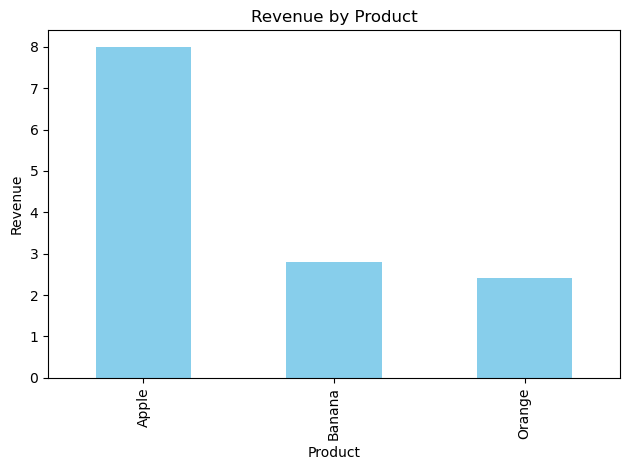

In [125]:
# Basic bar chart for revenue by product
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Optional: saves chart as PNG
plt.show()

In [126]:
# Adding More Products and Categories

In [127]:
# Always start with a new connection
conn1 = sqlite3.connect("sales_data.db")
cursor1 = conn1.cursor()

In [128]:
# Drop table if exists (for clean run in notebook)
cursor1.execute("DROP TABLE IF EXISTS sales")

In [129]:
# Create the updated 'sales' table with category
cursor1.execute("""
CREATE TABLE sales (
    id INTEGER PRIMARY KEY,
    product TEXT,
    category TEXT,
    quantity INTEGER,
    price REAL
)
""")

In [130]:
# Insert expanded product data with categories
sample_data = [
    ("Apple", "Fruits", 10, 0.5),
    ("Banana", "Fruits", 5, 0.2),
    ("Orange", "Fruits", 8, 0.3),
    ("Apple", "Fruits", 6, 0.5),
    ("Banana", "Fruits", 9, 0.2),
    ("Broccoli", "Vegetables", 4, 0.8),
    ("Carrot", "Vegetables", 7, 0.6),
    ("Spinach", "Vegetables", 5, 0.9),
    ("Milk", "Dairy", 10, 1.5),
    ("Cheese", "Dairy", 3, 2.5),
    ("Yogurt", "Dairy", 6, 1.2),
    ("Bread", "Bakery", 8, 1.0),
    ("Croissant", "Bakery", 4, 1.8)
]

In [131]:
# Insert data
cursor1.executemany("INSERT INTO sales (product, category, quantity, price) VALUES (?, ?, ?, ?)",sample_data)

In [132]:
# Save and close connection
conn1.commit()
conn1.close()
print(" Table reset and sample data inserted successfully.")

 Table reset and sample data inserted successfully.


In [133]:
# Connect with SQLite database
conn1 = sqlite3.connect("sales_data.db")
conn1

In [134]:
# Query with category
query1 = """
SELECT product, category,
       SUM(quantity) AS total_qty,
       ROUND(SUM(quantity * price), 2) AS revenue
FROM sales
GROUP BY product, category
ORDER BY category, product
"""

In [135]:
# Read query results into a DataFrame
df1 = pd.read_sql_query(query1, conn1)
conn1.close()

In [136]:
# Display result
print("Expanded Sales Summary:")
print(df1)

Expanded Sales Summary:
      product    category  total_qty  revenue
0       Bread      Bakery          8      8.0
1   Croissant      Bakery          4      7.2
2      Cheese       Dairy          3      7.5
3        Milk       Dairy         10     15.0
4      Yogurt       Dairy          6      7.2
5       Apple      Fruits         16      8.0
6      Banana      Fruits         14      2.8
7      Orange      Fruits          8      2.4
8    Broccoli  Vegetables          4      3.2
9      Carrot  Vegetables          7      4.2
10    Spinach  Vegetables          5      4.5


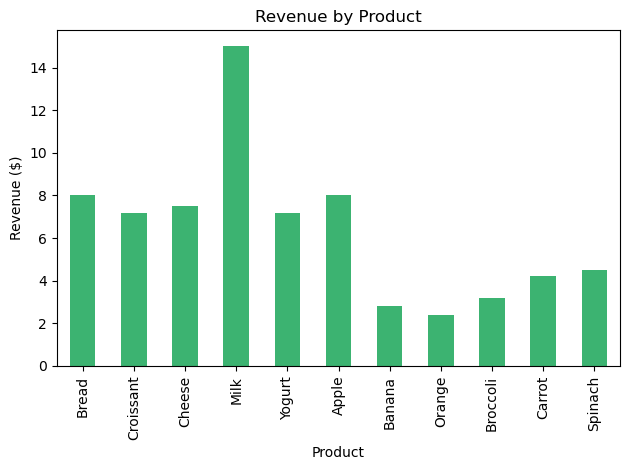

In [137]:
# Bar chart: revenue by product
df1.plot(kind='bar', x='product', y='revenue', legend=False, color='mediumseagreen')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("expanded_sales_chart.png")
plt.show()